In [1]:
from datasets import load_dataset
import numpy as np

#laod the dataset
full_dataset = load_dataset('food101', split='train')

# quickly find the indexes of the necessary classes (76 - pizza, 94 - cake)
labels = np.array(full_dataset['label'])
pizza_indices = np.where(labels == 76)[0][:500]
cake_indices = np.where(labels == 94)[0][:500]

#combine indexes
final_indices = np.concatenate([pizza_indices, cake_indices])

#final dataset only with two classes
dataset = full_dataset.select(final_indices).shuffle(seed=42)

print(dataset)

Dataset({
    features: ['image', 'label'],
    num_rows: 1000
})


In [2]:
# check count of each class.
pizza_count = len(dataset.filter(lambda x: x['label'] == 76))
cake_count = len(dataset.filter(lambda x: x['label'] == 94))

print(f"Count of images with pizza: {pizza_count}")
print(f"Count of images with cake: {cake_count}")

Count of images with pizza: 500
Count of images with cake: 500


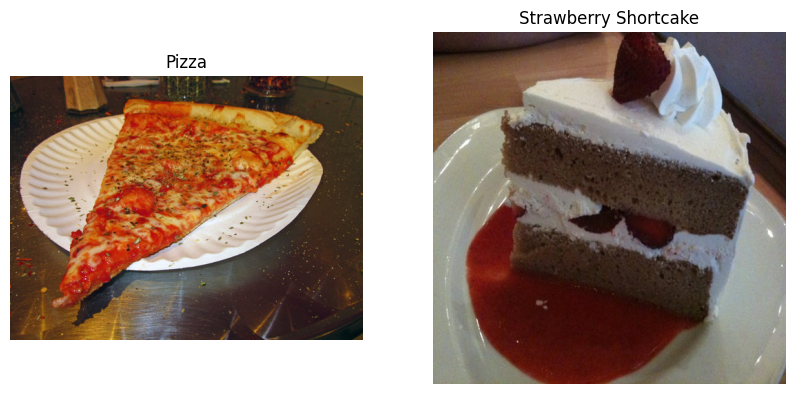

In [3]:
# plot images from each class.
import matplotlib.pyplot as plt

pizza_idx = dataset.filter(lambda x: x['label'] == 76)[0]
cake_idx = dataset.filter(lambda x: x['label'] == 94)[0]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(pizza_idx['image'])
ax[0].set_title("Pizza")
ax[0].axis('off')

ax[1].imshow(cake_idx['image'])
ax[1].set_title("Strawberry Shortcake")
ax[1].axis('off')

plt.show()

In [4]:
# creating train, val, test datasets.

train_test_split = dataset.train_test_split(test_size=0.1, seed=42)

train_val_split = train_test_split['train'].train_test_split(test_size=0.1, seed=42)

final_dataset = {
    'train': train_val_split['train'],
    'val': train_val_split['test'],
    'test': train_test_split['test']
}

print(f"Train: {len(final_dataset['train'])} images.")
print(f"Val: {len(final_dataset['val'])} images.")
print(f"Test: {len(final_dataset['test'])} images.")

Train: 810 images.
Val: 90 images.
Test: 100 images.


In [5]:
# Get names pf our two classes.
all_names = dataset.features["label"].names
target_labels = [all_names[76], all_names[94]]

id2label = {i: label for i, label in enumerate(target_labels)}
label2id = {label: i for i, label in id2label.items()}

# overwrite the labels in the dataset itself, so that there were 0 and 1 instead of 76 and 94
def rewrite_labels(example):
    example["label"] = 0 if example["label"] == 76 else 1
    return example

# Rewrite labels
for split in final_dataset:
    final_dataset[split] = final_dataset[split].map(rewrite_labels)

print(f"New id: {id2label}")
print(f"Example from train: {final_dataset['train'][0]['label']}")


New id: {0: 'pizza', 1: 'strawberry_shortcake'}
Example from train: 0


In [6]:
from transformers import ViTImageProcessor

# use tiny for correct work on CPU
model_name = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(model_name)

print(processor)

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [7]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    ToTensor,
    Resize,
)

# Get configurations from ViT processor
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"]

# Normalizes the image pixels by subtracting the mean and dividing by the std from the pretrained model configurations
normalize = Normalize(mean=image_mean, std=image_std)

# Compose: Combines a series of image transformations into one pipeline.
train_transforms = Compose(
    [
        RandomResizedCrop(size),
        RandomHorizontalFlip(),
        ToTensor(),
        normalize,
    ]
)
val_transforms = Compose(
    [
        Resize(size),
        CenterCrop(size),
        ToTensor(),
        normalize,
    ]
)
test_transforms = Compose(
    [
        Resize(size),
        CenterCrop(size),
        ToTensor(),
        normalize,
    ]
)

In [8]:
def apply_train_transforms(examples):
    examples["pixel_values"] = [
        train_transforms(image.convert("RGB")) for image in examples["image"]
    ]
    return examples

def apply_val_transforms(examples):
    examples["pixel_values"] = [
        val_transforms(image.convert("RGB")) for image in examples["image"]
    ]
    return examples

# assign these functions to our parts of the dataset
final_dataset['train'].set_transform(apply_train_transforms)
final_dataset['val'].set_transform(apply_val_transforms)
final_dataset['test'].set_transform(apply_val_transforms)

# check
print(final_dataset['train'][0].keys())

dict_keys(['image', 'label', 'pixel_values'])


In [9]:
import torch
from torch.utils.data import DataLoader


def collate_fn(examples):
    # Stacks the pixel values of all examples into a single tensor and collects labels into a tensor
    pixel_values = torch.stack([example["pixel_values"] for example in examples])

    labels = torch.tensor([example["label"] for example in examples])

    return {"pixel_values": pixel_values, "labels": labels}

# create a DataLoader for train and val
train_dl = DataLoader(final_dataset['train'], collate_fn=collate_fn, batch_size=4, shuffle=True)
val_dl = DataLoader(final_dataset['val'], collate_fn=collate_fn, batch_size=4)

# check in one batch
batch = next(iter(train_dl))
print(f"Format of image in one batch: {batch['pixel_values'].shape}")
print(f"Labels in one batch: {batch['labels']}")

Format of image in one batch: torch.Size([4, 3, 224, 224])
Labels in one batch: tensor([1, 0, 1, 1])


In [10]:
from transformers import ViTForImageClassification

# Two classes
num_labels = len(id2label)

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True # we need this line, it says: "throw away the old head for 1000 classes and put in a new one for 2"
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
from transformers import TrainingArguments, Trainer

train_args = TrainingArguments(
    output_dir="output-models",
    per_device_train_batch_size=4,
    eval_strategy="steps",
    num_train_epochs=5,
    fp16=False, # False - because it works only with NVIDIA
    save_steps=50,
    eval_steps=10,
    logging_steps=10,
    learning_rate=5e-5,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='tensorboard',
    load_best_model_at_end=True,
    use_cpu=True # Choose CPU
)

In [12]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=final_dataset['train'],
    eval_dataset=final_dataset['val'],
    data_collator=collate_fn, # our batches
    compute_metrics=compute_metrics,
    processing_class=processor,
)

In [13]:
trainer.train()


Step,Training Loss,Validation Loss,Accuracy
10,0.592470,0.478383,0.988889
20,0.413242,0.285862,1.000000
30,0.264524,0.158417,0.988889
40,0.137588,0.115553,0.955556
50,0.107424,0.089923,0.966667
60,0.072278,0.107740,0.955556
70,0.180481,0.085391,0.977778
80,0.037433,0.068392,0.977778
90,0.267432,0.110735,0.966667
100,0.024526,0.139522,0.955556


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1015, training_loss=0.06287923437254182, metrics={'train_runtime': 6629.7278, 'train_samples_per_second': 0.611, 'train_steps_per_second': 0.153, 'total_flos': 3.138425579390976e+17, 'train_loss': 0.06287923437254182, 'epoch': 5.0})

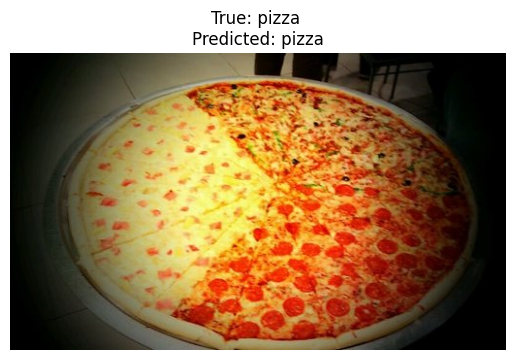

The model guessed!


In [14]:
import torch
import matplotlib.pyplot as plt

# take a random image from the test sample
test_sample = final_dataset['test'][11]
image = test_sample['image']
true_label = test_sample['label']

# preparing a picture for the model
# use our processor to make a tensor
inputs = processor(image.convert("RGB"), return_tensors="pt")

# make prediction
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()

# plot result
plt.imshow(image)
plt.title(f"True: {id2label[true_label]} \nPredicted: {id2label[predicted_class_idx]}")
plt.axis('off')
plt.show()

if true_label == predicted_class_idx:
    print("The model guessed!")
else:
    print("Error...")